In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import joblib
import json

pd.set_option('display.max_columns', None)

housing = pd.read_csv('/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv')
housing.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [20]:
print(housing.columns)
print(housing.shape)

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')
(187531, 21)


- **how many rows?** we have `187531` rows
- **how many columns are numberic?** 


In [21]:
print(housing.info())
print(housing.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [22]:
housing.isnull().sum()/housing.shape[0]*100

Index                  0.000000
Title                  0.000000
Description            1.612000
Amount(in rupees)      0.000000
Price (in rupees)      9.419776
location               0.000000
Carpet Area           43.018488
Status                 0.327946
Floor                  3.773776
Transaction            0.044259
Furnishing             1.544811
facing                37.451408
overlooking           43.425354
Society               58.485264
Bathroom               0.441527
Balcony               26.094352
Car Parking           55.114621
Ownership             34.936624
Super Area            57.422506
Dimensions           100.000000
Plot Area            100.000000
dtype: float64

the columns `Dimensions`, `Plot Area`, `Super Area`, `Car Parking`, `society`, `overlooking`

## cleaning

### numerical columns

In [23]:
housing = housing.drop(columns=['Index','Title','Description','Dimensions',
                                'Plot Area', 'Car Parking', 'Super Area',
                               'Price (in rupees)', 'Society'])
housing.columns

Index(['Amount(in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Bathroom',
       'Balcony', 'Ownership'],
      dtype='object')

In [24]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if 'lac' in x:
            return float(x.replace('lac', '').strip()) * 1e5
        if 'cr' in x:
            return float(x.replace('cr', '').strip()) * 1e7
        return float(x.replace(',', ''))
    except ValueError:
        return None

def parse_Floor(x):
    if not isinstance(x, str):
        return None
    floor_num = x.lower().split()[0]
    try: 
        if floor_num == 'lower basement':
            floor_num = -2
        elif floor_num == 'upper basement':
            floor_num = -1
        elif floor_num == 'ground':
            floor_num = 0
        else:
            floor_num = int(floor_num)
        return floor_num
    except ValueError:
        return None

def parse_Area(x):
    if not isinstance(x, str) or len(x.split()) != 2:
        return None
    x = x.lower().replace(',','').split()
    try:
        if x[1] == 'sqm':
            return float(x[0]) * 10.764
        elif x[1] == 'sqyrd':
            return float(x[0]) * 9
        elif x[1] == 'sqft':
            return float(x[0])
    except ValueError:
        return None    

def parse_Bath_Balcony(x):
    if not isinstance(x, str):
        return None
    x = x.lower().strip()
    try:
        if x == '> 10':
            return 11
        else:
            return float(x)
    except ValueError:
        return None 

In [25]:
housing['price_clean'] = housing['Amount(in rupees)'].apply(parse_amount)
housing['floor_num'] = housing['Floor'].apply(parse_Floor)
housing['carpet_area_sqft'] = housing['Carpet Area'].apply(parse_Area)
housing['Bathroom'] = housing['Bathroom'].apply(parse_Bath_Balcony)
housing['Balcony'] = housing['Balcony'].apply(parse_Bath_Balcony)

housing = housing.dropna(subset=['price_clean'])
housing = housing.drop(columns=['Floor', 'Carpet Area', 'Amount(in rupees)'])
price_clean_log = np.log1p(housing['price_clean'])

### categorical columns

In [26]:
housing['Status'].unique()

array(['Ready to Move', nan], dtype=object)

as `status` is a one category column we can neglect it

In [27]:
housing = housing.drop(columns=['Status'])

In [28]:
print(housing.info())
print(housing.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   location          177847 non-null  object 
 1   Transaction       177780 non-null  object 
 2   Furnishing        175780 non-null  object 
 3   facing            112111 non-null  object 
 4   overlooking       102022 non-null  object 
 5   Bathroom          177087 non-null  float64
 6   Balcony           130688 non-null  float64
 7   Ownership         115922 non-null  object 
 8   price_clean       177847 non-null  float64
 9   floor_num         170563 non-null  float64
 10  carpet_area_sqft  101514 non-null  float64
dtypes: float64(5), object(6)
memory usage: 16.3+ MB
None
location                0
Transaction            67
Furnishing           2067
facing              65736
overlooking         75825
Bathroom              760
Balcony             47159
Ownership           61925
pric

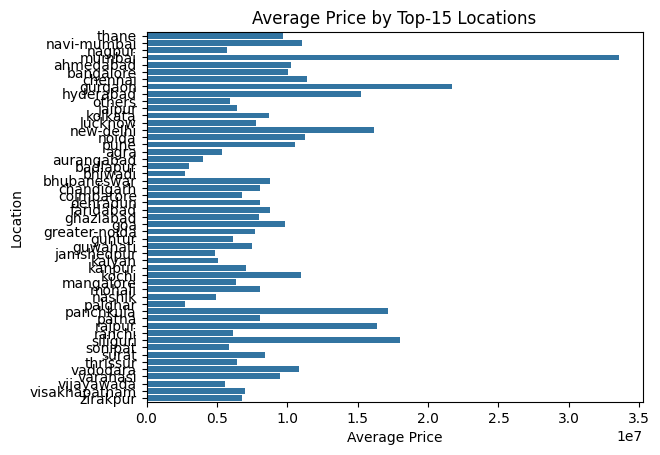

In [29]:
top_50 = housing['location'].value_counts().index[:50]
housing['location_grouped'] = housing['location'].where(housing['location'].isin(top_50),other='others')
sns.barplot(
    data=housing,
    x="price_clean",
    y="location_grouped",
    estimator="mean",
    errorbar=None,
)
plt.title("Average Price by Top-15 Locations")
plt.xlabel("Average Price")
plt.ylabel("Location")
plt.show()

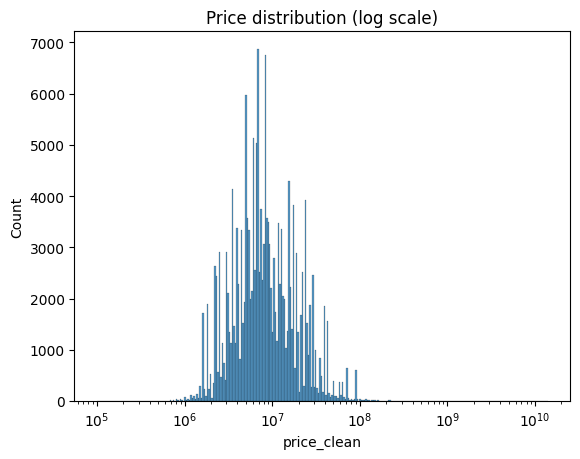

In [30]:
sns.histplot(housing["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

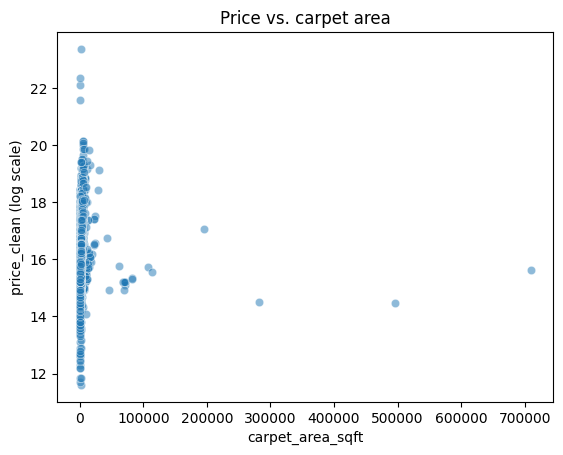

In [31]:
sns.scatterplot(data=housing, x="carpet_area_sqft", y=price_clean_log, alpha=0.5)
plt.title('Price vs. carpet area')
plt.xlabel('carpet_area_sqft')
plt.ylabel('price_clean (log scale)')
plt.show()

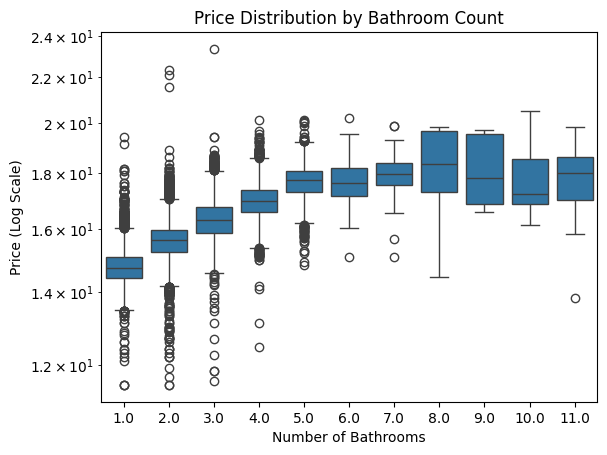

In [32]:
sns.boxplot(data=housing, x="Bathroom", y=price_clean_log)
plt.yscale("log")
plt.title("Price Distribution by Bathroom Count")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price (Log Scale)")
plt.show()

In [33]:
price_per_sqft = housing['price_clean']/housing['carpet_area_sqft']

lower_limit = price_per_sqft.quantile(0.01)
upper_limit = price_per_sqft.quantile(0.99)

housing = housing[(
    (price_per_sqft >= lower_limit) &
    (price_per_sqft <= upper_limit)
)]

In [34]:
numeric_features = ['carpet_area_sqft', 'floor_num', 'Bathroom', 'Balcony']
categorical_features = ['location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing']

X = housing[numeric_features + categorical_features] 
y = housing['price_clean'] 

preprocessor = ColumnTransformer([ 
('num', Pipeline([('impute', SimpleImputer(strategy='median')), 
('scale', StandardScaler())]), numeric_features), 
('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), 
('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features), 
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [35]:
models_without_log = {
    'LinearRegression': LinearRegression(),
    'RandomForest' : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    }

for name,model_without_log in models_without_log.items():
    model = Pipeline([('prep', preprocessor), (name,model_without_log)]) 
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    
    print(f"{name}:")
    print('='*40)
    print('MAE :', mean_absolute_error(y_test, pred)) 
    print('RMSE:', root_mean_squared_error(y_test, pred)) 
    print('R² :', r2_score(y_test, pred))
    print('='*40)

LinearRegression:
MAE : 4128890.2066967543
RMSE: 6585688.666413951
R² : 0.741091737264167
RandomForest:
MAE : 965768.8513144156
RMSE: 3185376.741396095
R² : 0.9394289463889565


In [37]:
models_with_log = {
    'LinearRegression_log':LinearRegression(),
    'ٌRandomForest_log' : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    }

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

for name, model_with_log in models_with_log.items():
    model = Pipeline([('prep', preprocessor), (name,model_with_log)]) 
    model.fit(X_train, y_train_log)

    pred_log = model.predict(X_test)
    pred_log = np.clip(pred_log, a_min=y_train_log.min(), a_max=y_train_log.max())
    pred = np.expm1(pred_log)
    
    print(f"{name}:")
    print('='*40)
    print('MAE :', mean_absolute_error(y_test, pred)) 
    print('RMSE:', root_mean_squared_error(y_test, pred)) 
    print('R² :', r2_score(y_test, pred))
    print('='*40)

LinearRegression_log:
MAE : 4236170.451482653
RMSE: 12313054.629104367
R² : 0.09494466777106514
ٌRandomForest_log:
MAE : 954836.4275912124
RMSE: 3265476.659472031
R² : 0.9363443896511234


and by this the winner is RandomForest with log transform

In [39]:
joblib.dump(model, "house_price.pkl", compress=3)
# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
json.dump(sorted(housing["location_grouped"].unique().tolist()), open("locations.json", "w"))

Reloaded prediction: [15.52025883]
